# Модуль 1. Алгоритмы на основе деревьев решений

## Деревья решений. Алгоритм CART

**CART (Classification and Regression Tree)** - алгоритм и предназначенный для построения бинарных деревьев решений (деревьев, у которых каждая вершина связана с двумя другими вершинами нижнего уровня). Алгоритм очень похож на C4.5, однако в отличие от последнего предназначен как для задач классификации, так и для задач регрессии. CART важен для нас поскольку, именно он используется для построения моделей решающих деревьев в sklearn.


## 3/10   Алгоритм CART: параметры разбиения

В качестве **резюме** приведём наш оптимизированный алгоритм определения пороговых значений для фактора $x_j$:

1. Отсортировать числовой фактор $x_j$ по возрастанию:

$\{x_{ij}\ \mid \ x_{ij}<x_{(i+1)j}\}$

2. Вычислить среднее между двумя соседними уникальными значениями фактора:

${{\{x}_{ij}}^{mean} \mid {{\ x}_{ij}}^{mean}=\frac{x_{ij}+x_{(i+1)j}}{2}\}$

3. В качестве кандидатов на пороговые значений  выбираются только те значения, при которых целевой признак меняет своё значение:

${\{x_{ij}}^{mean} \mid \ y_i-y_{(i+1)}\neq 0\}$



Воспользуемся данными о недвижимости в штате Айова из Ames Housing Dataset. Это классическая задача предсказания цены недвижимости.

Для примера визуализации из всех признаков, описывающих объекты недвижимости, мы выберем:

Lot_Frontage — ширина фасада;
Lot_Area — площадь объекта недвижимости.
Необходимо предсказать стоимость недвижимости (Sale_Price). Файл с данными вы можете скачать здесь.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn import tree

Примечание. Для более понятной визуализации перед построением дерева уберём из датасета объекты с Lot_Frontage > 150 и с Lot_Area > 20000.

In [17]:
# Создаём обучающую выборку
ames_data = pd.read_csv('data/AmesHousing.csv')
ames_data = ames_data[(ames_data['Lot Frontage'] <=150) & (ames_data['Lot Area'] <=20000)]
X = ames_data[['Lot Frontage', 'Lot Area']]
y = ames_data['SalePrice']

In [18]:
# Инициализируем модель дерева решений с максимальной глубиной 3 и обучаем её
dt_reg = tree.DecisionTreeRegressor(max_depth=3)
dt_reg.fit(X.values, y)

DecisionTreeRegressor(max_depth=3)

Отследить, как дерево решений строит свой прогноз, нам может помочь граф обученного дерева решений. Напомним, что за его визуализацию в библиотеке sklearn отвечает функция plot_tree() из модуля tree.

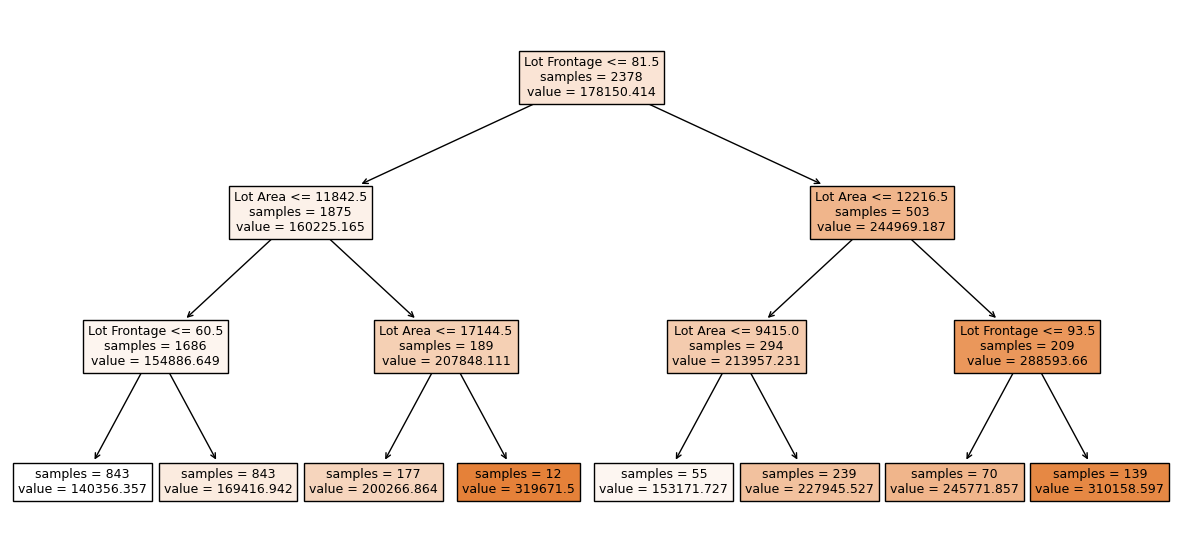

In [19]:
# Визуализируем дерево решений в виде графа
fig = plt.figure(figsize=(15, 7))
tree_graph = tree.plot_tree(
    dt_reg, #дерево решений 
    feature_names=list(X.columns), #имена факторов
    filled=True, #расцветка
    impurity=False, #отображать ли неоднородность
);

Построим диаграмму рассеяния и визуализируем то, как дерево решений разделяет пространство факторов на прямоугольные области. Для этого шага мы реализовали функцию plot_decision_bound_regression():

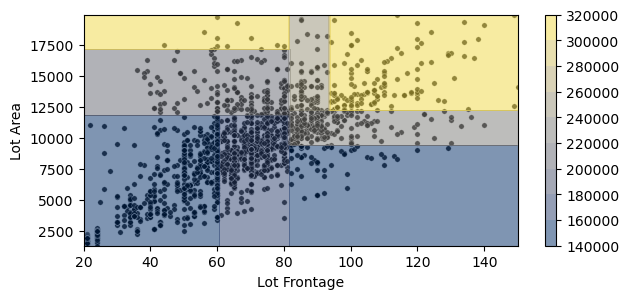

In [21]:
def plot_decision_bound_regression(X, y, model, fig):
    xx1, xx2 = np.meshgrid(
        np.arange(X.iloc[:, 0].min()-1, X.iloc[:, 0].max()+1, 1),
        np.arange(X.iloc[:, 1].min()-1, X.iloc[:, 1].max()+1, 1)
    )
    X_net = np.hstack([xx1.reshape(-1, 1), xx2.reshape(-1, 1)])
    y_pred = model.predict(X_net)
    y_pred = y_pred.reshape(xx1.shape)
    sns.scatterplot(x=X.iloc[:, 0], y=X.iloc[:, 1], s=15, color='black', alpha=0.8)
    contour = plt.contourf(xx1, xx2, y_pred, 10, cmap='cividis', alpha=0.5)
    fig.colorbar(contour)

# Визуализируем разделяющую поверхность дерева решений
fig = plt.figure(figsize = (7, 3))
plot_decision_bound_regression(X, y, dt_reg, fig)

Что мы здесь видим? В результате построения дерева решений было образовано восемь областей ($R_1, R_2,..., R_8$), соответствующих каждому из восьми листьев. В каждой из областей было рассчитано предсказание дерева для этой области  — среднее арифметическое целевой переменной  (они отражены на тепловой шкале справа от диаграммы) по формуле, приведённой выше.

Прогноз для нового объекта будет определяться в зависимости от того, в какую из полученных областей он попадёт.

In [6]:
# Создаём обучающую выборку    
bill_data = pd.read_csv('data/bill_authentication.csv')
X = bill_data[['Variance', 'Skewness']]
y = bill_data['Class']

In [7]:
# Инициализируем модель дерева решений с максимальной глубиной 4 и обучаем её
dt_clf = tree.DecisionTreeClassifier(max_depth=4)
dt_clf.fit(X.values, y)

DecisionTreeClassifier(max_depth=4)

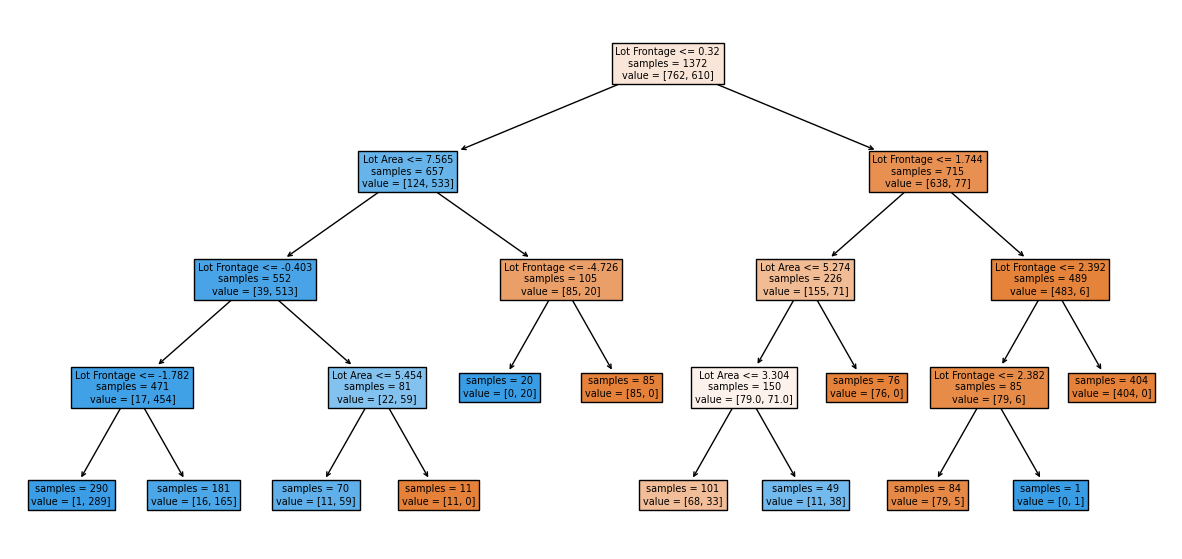

In [56]:
# Визуализируем дерево решений в виде графа
fig = plt.figure(figsize=(15, 7))
tree_graph = tree.plot_tree(
    dt_clf, #дерево решений
    feature_names=list(X.columns), #имена факторов
    filled=True, #расцветка
    impurity=False, #отображать ли неоднородность
);

В результате построения дерева было образовано 12 областей (), каждая из которых соответствует одному из 12 листьев. В каждой из областей была рассчитана оценка вероятности принадлежности к каждому из классов — . Класс объекта  определяется как класс с максимальной из этих вероятностей.

Построим диаграмму рассеяния и визуализируем то, как дерево решений разделяет пространство факторов на прямоугольные области. Для этого шага мы реализовали функцию plot_decision_bound_classification():

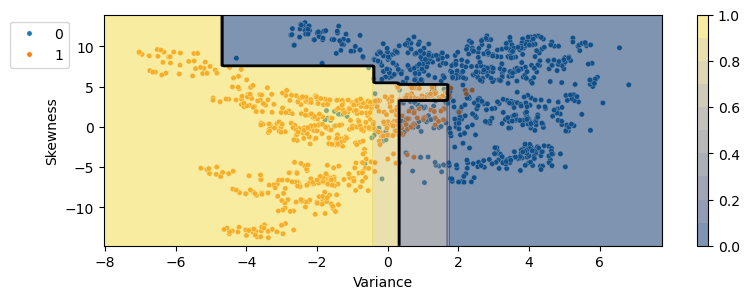

In [9]:
def plot_decision_bound_classification(X, y, model, fig):
    xx1, xx2 = np.meshgrid(
        np.arange(X.iloc[:, 0].min()-1, X.iloc[:, 0].max()+1, 0.1),
        np.arange(X.iloc[:, 1].min()-1, X.iloc[:, 1].max()+1, 0.1)
    )
    X_net = np.hstack([xx1.reshape(-1, 1), xx2.reshape(-1, 1)])
    probs = model.predict_proba(X_net)[:, 1]
    probs = probs.reshape(xx1.shape)
    
    sns.scatterplot(x=X.iloc[:, 0], y=X.iloc[:, 1], hue=y, s=15, alpha=1)
    contour = plt.contourf(xx1, xx2, probs, 10, cmap='cividis', alpha=0.5)
    bound = plt.contour(xx1, xx2, probs, [0.5], linewidths=2, colors='black');
    fig.colorbar(contour)
    plt.legend(bbox_to_anchor=(-0.05, 1))
# Визуализируем разделяющую поверхность дерева решений
fig = plt.figure(figsize = (9, 3))
plot_decision_bound_classification(X, y, dt_clf, fig)

**Задание 3.4**

Дана часть датасета о домах в штате Айова, состоящая из 15 наблюдений:

In [10]:
import pandas as pd

ames_data = pd.read_csv('data/AmesHousing.csv')
ames_data = ames_data[(ames_data['Lot Frontage'] <=150) & (ames_data['Lot Area'] <=20000)]
ames_sample = ames_data[['Lot Frontage', 'Lot Area', 'SalePrice']].sample(
    n=15, #количество объектов
    random_state=42, #генератор случайных чисел
    ignore_index=True #сбрасываем счетчик индекса
)

Найдите уникальных кандидатов на пороговое значение  для фактора  (Lot Frontage).

Выберите верный вариант ответа:

In [11]:
data = ames_sample
x = data['Lot Frontage']
y = data['SalePrice']

# сортируем и удаляем дубликаты
x = x.sort_values().drop_duplicates()

x_roll_mean = x.rolling(2).mean()
x_roll_mean = x_roll_mean.dropna()

y = y[x_roll_mean.index]
y_roll_mean = y.diff()

candidates = x_roll_mean[y_roll_mean != 0]
candidates

8      53.0
0      58.0
14     61.0
2      65.0
9      69.0
7      71.0
5      76.0
4      86.0
1      94.0
12    101.0
Name: Lot Frontage, dtype: float64

**Задание 3.5**

Для части датасета о домах в Айове из предыдущего задания найдите уникальных кандидатов на пороговое значение  для фактора  (Lot Area).

Выберите верный вариант ответа:

In [12]:
data = ames_sample
x = data['Lot Area']
y = data['SalePrice']

# сортируем и удаляем дубликаты
x = x.sort_values().drop_duplicates()

x_roll_mean = x.rolling(2).mean()
x_roll_mean = x_roll_mean.dropna()

y = y[x_roll_mean.index]
y_roll_mean = y.diff()

candidates = x_roll_mean[y_roll_mean != 0]
candidates

8      5508.0
6      7153.0
14     7425.0
13     7949.0
12     8405.5
7      8526.5
3      8850.0
4      9137.5
2      9466.0
5     10051.5
1     10507.0
0     10834.0
11    11365.0
9     12288.0
Name: Lot Area, dtype: float64

## 4/10   Алгоритм CART: неоднородность, критерии информативности

**Задание 4.3**

Дана часть датасета о домах в штате Айова, состоящая из 15 наблюдений:

In [24]:
ames_data = ames_data[(ames_data["Lot Frontage"] <=150) & (ames_data["Lot Area"] <=20000)]

ames_sample = ames_data[["Lot Frontage", "Lot Area", "SalePrice"]].sample(
    n=15, random_state=42, ignore_index=True
)

X = ames_sample[["Lot Frontage", "Lot Area"]]
y = ames_sample["SalePrice"]

Найдите оптимальные для построения решающего пня параметры разбиения $j$ и $t$. В качестве критерия информативности используйте квадратичную ошибку.

Примечание. Для самопроверки обучите на данной части датасета дерево решений из sklearn с максимальной глубиной 1, критерием информативности 'squared_error' и параметром random_state = 0 и визуализируйте его граф.

In [86]:
# Форматирование всех столбцов с помощью функции
ames_sample.style.format(lambda x: f'{x:,.0f}')

# Форматирование отдельных столбцов с помощью словаря
# df.style.format({'A': lambda x: f'{x:.2f}', 'B': lambda x: f'{x:.3f}'})

,Lot Frontage,Lot Area,SalePrice
0,60,"11,040","108,000"
1,96,"10,628","193,000"
2,68,"9,717","142,125"
3,50,"9,060","150,909"
4,92,"9,215","204,500"
5,80,"10,386","305,900"
6,60,"7,350","139,000"
7,72,"8,640","229,800"
8,56,"6,956","97,900"
9,70,"12,886","175,000"


In [87]:
ames_sample

,Lot Frontage,Lot Area,SalePrice
0,60.0,11040,108000
1,96.0,10628,193000
2,68.0,9717,142125
3,50.0,9060,150909
4,92.0,9215,204500
5,80.0,10386,305900
6,60.0,7350,139000
7,72.0,8640,229800
8,56.0,6956,97900
9,70.0,12886,175000


In [34]:
x = ames_sample["Lot Frontage"]
x.sort_values()

3      50.0
8      56.0
10     56.0
13     56.0
0      60.0
6      60.0
14     62.0
2      68.0
9      70.0
7      72.0
5      80.0
4      92.0
1      96.0
11     96.0
12    106.0
Name: Lot Frontage, dtype: float64

In [36]:
x = ames_sample["Lot Area"]
x.sort_values()

10     4060
8      6956
6      7350
14     7500
13     8398
12     8413
7      8640
3      9060
4      9215
2      9717
5     10386
1     10628
0     11040
11    11690
9     12886
Name: Lot Area, dtype: int64

In [35]:
y.sort_values()

8      97900
10     99900
0     108000
6     139000
2     142125
13    144100
3     150909
9     175000
14    176000
1     193000
4     204500
11    207000
7     229800
5     305900
12    312500
Name: SalePrice, dtype: int64

In [58]:
def find_candidates_for_thresholds(x, y):
    x = x.sort_values().drop_duplicates()
    x_roll_mean = x.rolling(2).mean().dropna()
    y = y[x_roll_mean.index]
    y_roll_mean = y.diff()
    candidates = x_roll_mean[y_roll_mean != 0]
    return candidates.values

In [59]:
data = ames_sample
print(find_candidates_for_thresholds(data['Lot Frontage'], data['SalePrice']))
print(find_candidates_for_thresholds(data['Lot Area'], data['SalePrice']))

[ 53.  58.  61.  65.  69.  71.  76.  86.  94. 101.]
[ 5508.   7153.   7425.   7949.   8405.5  8526.5  8850.   9137.5  9466.
 10051.5 10507.  10834.  11365.  12288. ]


Для начала создадим функцию для расчёта среднего квадрата ошибки — squared_error(). Она будет принимать на вход истинные ответы и возвращать значение MSE, рассчитанное для входных данных.

In [62]:
def squared_error(y):
    y_pred = y.mean()
    return ((y - y_pred) ** 2).mean()

In [63]:
y

0     108000
1     193000
2     142125
3     150909
4     204500
5     305900
6     139000
7     229800
8      97900
9     175000
10     99900
11    207000
12    312500
13    144100
14    176000
Name: SalePrice, dtype: int64

In [64]:
squared_error(y)

4066908207.262222

Далее нам необходимо реализовать функцию split(), которая разбивает выборку  по предикату  с параметрами разделения (split_params) на левую и правую части:

In [69]:
def split(X, y, split_params):
    j, t = split_params
    predicat = X.iloc[:, j] <= t
    X_left, y_left = X[predicat], y[predicat]
    X_right, y_right = X[~predicat], y[~predicat]
    return X_left, y_left, X_right, y_right

In [70]:
split_params = [0, 71]

In [71]:
split(X, y, split_params)

(    Lot Frontage  Lot Area
 0           60.0     11040
 2           68.0      9717
 3           50.0      9060
 6           60.0      7350
 8           56.0      6956
 9           70.0     12886
 10          56.0      4060
 13          56.0      8398
 14          62.0      7500,
 0     108000
 2     142125
 3     150909
 6     139000
 8      97900
 9     175000
 10     99900
 13    144100
 14    176000
 Name: SalePrice, dtype: int64,
     Lot Frontage  Lot Area
 1           96.0     10628
 4           92.0      9215
 5           80.0     10386
 7           72.0      8640
 11          96.0     11690
 12         106.0      8413,
 1     193000
 4     204500
 5     305900
 7     229800
 11    207000
 12    312500
 Name: SalePrice, dtype: int64)

Затем создадим функцию calculate_weighted_impurity(). Она будет принимать на вход выборку — X и y, параметры разбиения — split_params, а также criterion — функцию, по которой рассчитывается критерий информативности (у нас это функция squared_error()). Результатом работы функции будет взвешенная неоднородность после разбиения.

In [80]:
criterion = squared_error

In [81]:
def calculate_weighted_impurity(X, y, split_params, criterion):
    X_left, y_left, X_right, y_right = split(X, y, split_params)
    N, N_left, N_right  = y.size, y_left.size, y_right.size
    score = N_left / N * criterion(y_left) + N_right / N * criterion(y_right)
    return score

In [82]:
calculate_weighted_impurity(X, y, split_params, criterion)

1414654917.0222223

Наконец, финальный шаг — построить решающий пень. Для этого необходимо оформить в виде цикла отбор кандидатов в параметры разбиения и найти оптимальные из них. За данный шаг будет отвечать функция best_split(). Она будет принимать на вход выборку (X и y) и возвращать оптимальные параметры разбиения, при которых значение взвешенной неоднородности минимально, а также значение этой неоднородности.

In [88]:
def best_split(X, y, criterion):
    M = X.shape[1]
    min_weighted_impurity = np.inf
    optimal_split_params = None
    for j in range(M):
        thresholds = find_candidates_for_thresholds(X.iloc[:, j], y)
        for t in thresholds:
            split_params = (j, t)
            weighted_impurity = calculate_weighted_impurity(X, y, split_params, criterion)
            if weighted_impurity < min_weighted_impurity:
                min_weighted_impurity = weighted_impurity
                optimal_split_params = split_params
    return optimal_split_params

In [89]:
best_split(X, y, criterion)

(0, 71.0)

Примечание. При выполнении поиска оптимальных параметров сплита возможно возникновение такой ситуации, когда взвешенная неоднородность для двух разных наборов параметров будет одинаковой. В нашей реализации такие ситуации не учитываются: выбирается первый встретившийся вариант параметров с наименьшей взвешенной неоднородностью.

В sklearn такие случаи обрабатываются следующим образом: из всех наборов параметров разбиения, для которых неоднородность после сплита минимальна из возможных и при этом одинакова, случайным образом выбирается только один этих наборов. Поэтому иногда деревья, полученные с помощью нашего кода, и деревья из sklearn могут не совпадать. Для получения этого совпадения при работе с деревьями из sklearn необходимо задать параметр random_state. Мы будем указывать это в явном виде при формулировании заданий.

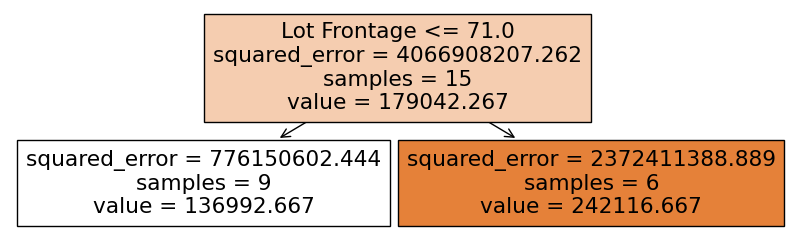

In [60]:
# Инициализируем модель дерева решений с максимальной глубиной 1 и обучаем её
dt_reg = tree.DecisionTreeRegressor(max_depth=1, criterion='squared_error', random_state=0)
dt_reg.fit(X.values, y)

# Визуализируем дерево решений в виде графа
fig = plt.figure(figsize=(10, 3))
tree_graph = tree.plot_tree(
    dt_reg, #дерево решений 
    feature_names=list(X.columns), #имена факторов
    filled=True, #расцветка
    impurity=True, #отображать ли неоднородность
);

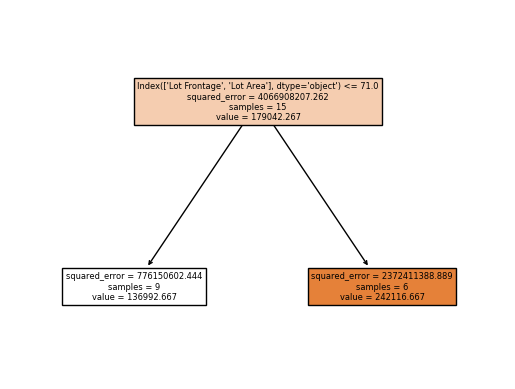

In [41]:
# Инициализируем модель дерева решений с максимальной глубиной 1 и обучаем ее
dt = tree.DecisionTreeRegressor(
    max_depth=1, #глубина
    criterion='squared_error', #критерий информативности
    random_state=0 #генератор случайных чисел
)
dt.fit(X, y)

# Визуализируем дерево решений в виде графа
tree.plot_tree(
    decision_tree=dt, #дерево решений 
    feature_names=[X.columns], #имена факторов
    filled=True, #расцветка
    impurity=True, #отображать ли неоднородность в вершинах
);

In [15]:
ames_sample.describe()

,Lot Frontage,Lot Area,SalePrice
count,15.000000,15.000000,15.000000
mean,72.000000,9062.600000,179042.266667
std,17.792454,2170.678261,66010.617711
min,50.000000,4060.000000,97900.000000
25%,58.000000,7949.000000,140562.500000
50%,68.000000,9060.000000,175000.000000
75%,86.000000,10507.000000,205750.000000
max,106.000000,12886.000000,312500.000000


In [16]:
ames_sample.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Lot Frontage  15 non-null     float64
 1   Lot Area      15 non-null     int64  
 2   SalePrice     15 non-null     int64  
dtypes: float64(1), int64(2)
memory usage: 492.0 bytes
